# Support Vector Machine Classification
Solving SVM to find the hyperplane and predict a test point.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Load the dataset
data_path = r'../data/svm_dataset.csv'
df = pd.read_csv(data_path)
df.head()

,Feature1,Feature2,Target
0,1.0,1.5,-1
1,1.2,2.0,-1
2,1.8,1.0,-1
3,1.5,1.5,-1
4,2.0,2.5,-1


In [7]:
# Split into features and target
X = df[['Feature1', 'Feature2']].values
y = df['Target'].values

# Fit SVM (linear kernel to easily extract hyperplane)
clf = SVC(kernel='linear', C=10)
clf.fit(X, y)

print("Model training complete.")

Model training complete.


In [8]:
# Finding the hyperplane (w * x + b = 0)
w = clf.coef_[0]
b = clf.intercept_[0]

print("Hyperplane parameters:")
print(f"Weights (w): {w}")
print(f"Intercept (b): {b:.4f}")
print("\nHyperplane equation:")
print(f"{w[0]:.4f} * x1 + {w[1]:.4f} * x2 + {b:.4f} = 0")

Hyperplane parameters:
Weights (w): [0.5 0.5]
Intercept (b): -3.2500

Hyperplane equation:
0.5000 * x1 + 0.5000 * x2 + -3.2500 = 0


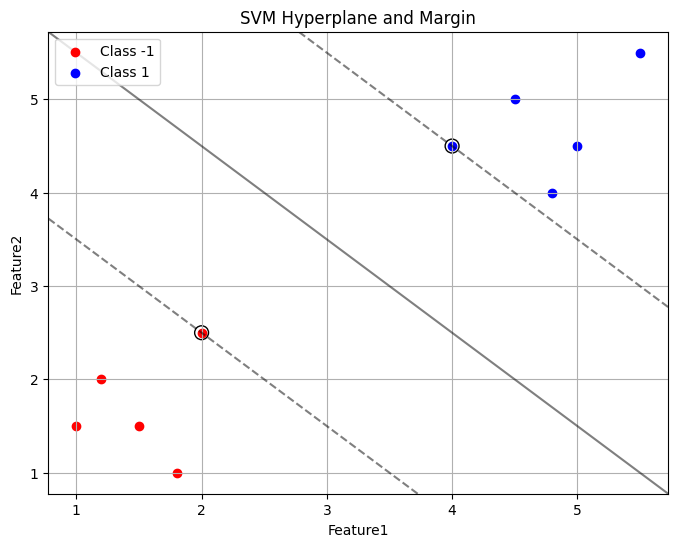

In [9]:
# Plotting the data and hyperplane
plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(X[y==-1][:, 0], X[y==-1][:, 1], color='red', label='Class -1')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='Class 1')

# Create a grid to evaluate model
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Get decision boundary
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Highlight support vectors
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100, linewidth=1, facecolors='none', edgecolors='k')

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.title("SVM Hyperplane and Margin")
plt.grid(True)
plt.show()

The test point [3.0, 3.5] belongs to class 1


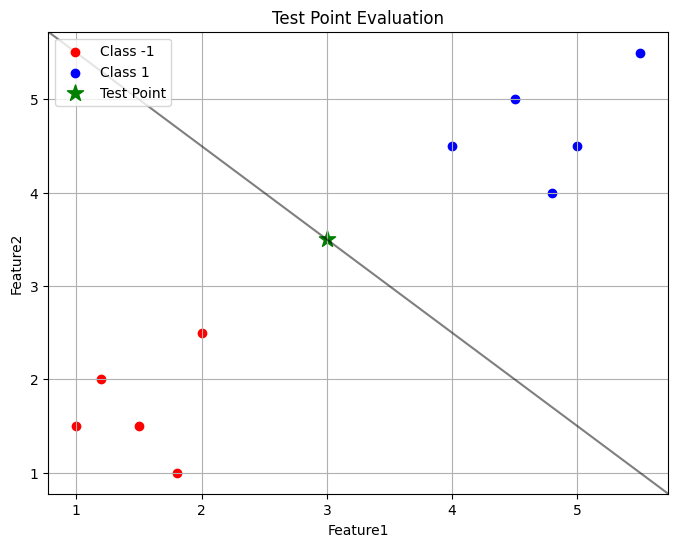

In [10]:
# Test point evaluation
test_point = [[3.0, 3.5]] # You can change this to be whatever test point you wish to evaluate
prediction = clf.predict(test_point)

print(f"The test point {test_point[0]} belongs to class {prediction[0]}")

# Plotting the test point along with the rest
plt.figure(figsize=(8, 6))
plt.scatter(X[y==-1][:, 0], X[y==-1][:, 1], color='red', label='Class -1')
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='Class 1')

ax = plt.gca()
ax.contour(XX, YY, Z, colors='k', levels=[0], alpha=0.5, linestyles=['-'])

plt.scatter(test_point[0][0], test_point[0][1], color='green', s=150, marker='*', label='Test Point')

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.title("Test Point Evaluation")
plt.grid(True)
plt.show()